# 17. Self-Refine sobre los dos mejores sistemas LoRA

Este notebook aplica una etapa de Self-Refine sobre los dos mejores sistemas obtenidos en la evaluación integral cuantitativa + cualitativa:

1. `lora_mistral`
2. `lora_llama3`

El objetivo no es generar una simplificación desde cero, sino realizar una post-edición controlada sobre la salida inicial para:

- reducir copias literales del texto original,
- simplificar vocabulario formal,
- mantener fidelidad semántica,
- mejorar claridad,
- usar viñetas solo cuando ayuden,
- conservar números, nombres propios y datos importantes.

El modelo refinador será `llama3`, definido en `configs/models.py`, que apunta a `llama3:8b` en Ollama.

Los nuevos sistemas generados serán:

- `lora_mistral_self_refine_llama3`
- `lora_llama3_self_refine_llama3`

In [1]:
from pathlib import Path
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path("/home/harielpadillasanchez/Documentos/TT/TT2")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

INTEGRAL_DIR = PROJECT_ROOT / "outputs" / "evaluacion_integral_lora_vs_hiperparametros"
DETAIL_PATH = INTEGRAL_DIR / "detalle_216_cuantitativo_cualitativo.csv"
RANKING_PATH = INTEGRAL_DIR / "ranking_integral_cuantitativo_cualitativo.csv"

OUT_DIR = PROJECT_ROOT / "outputs" / "self_refine_top2_lora"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT, "| existe:", PROJECT_ROOT.exists())
print("DETAIL_PATH:", DETAIL_PATH, "| existe:", DETAIL_PATH.exists())
print("RANKING_PATH:", RANKING_PATH, "| existe:", RANKING_PATH.exists())
print("OUT_DIR:", OUT_DIR)

if not DETAIL_PATH.exists():
    raise FileNotFoundError(DETAIL_PATH)

PROJECT_ROOT: /home/harielpadillasanchez/Documentos/TT/TT2 | existe: True
DETAIL_PATH: /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/detalle_216_cuantitativo_cualitativo.csv | existe: True
RANKING_PATH: /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/ranking_integral_cuantitativo_cualitativo.csv | existe: True
OUT_DIR: /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora


In [2]:
TOP_SYSTEMS = [
    "lora_mistral",
    "lora_llama3",
]

REFINER_MODEL_KEY = "llama3"

SELF_REFINE_SUFFIX = f"_self_refine_{REFINER_MODEL_KEY}"

# Para edición conservadora.
SELF_REFINE_TEMPERATURE = 0.01
SELF_REFINE_TOP_P = 0.8
SELF_REFINE_MAX_TOKENS = 256

# Si quieres probar rápido primero, usa True y limita a pocos ejemplos.
DEBUG_RUN = False
DEBUG_N = 6

print("Sistemas base:")
for s in TOP_SYSTEMS:
    print("-", s)

print("\nModelo refinador:", REFINER_MODEL_KEY)
print("Sufijo:", SELF_REFINE_SUFFIX)
print("Temperature:", SELF_REFINE_TEMPERATURE)
print("Top-p:", SELF_REFINE_TOP_P)
print("Max tokens:", SELF_REFINE_MAX_TOKENS)

Sistemas base:
- lora_mistral
- lora_llama3

Modelo refinador: llama3
Sufijo: _self_refine_llama3
Temperature: 0.01
Top-p: 0.8
Max tokens: 256


In [3]:
from configs.models import MODELS, DEFAULT_GENERATION_CONFIG

print("Modelos disponibles:")
for key, cfg in MODELS.items():
    print(key, "->", cfg)

if REFINER_MODEL_KEY not in MODELS:
    raise ValueError(f"No existe {REFINER_MODEL_KEY} en configs.models.MODELS")

model_cfg = MODELS[REFINER_MODEL_KEY]

print("\nModelo refinador seleccionado:")
print(model_cfg)

if model_cfg["backend"] != "ollama":
    raise ValueError("Para este notebook se espera un modelo con backend='ollama'.")

print("\nRuntime Ollama:", model_cfg["runtime_name"])

Modelos disponibles:
bloomz_small -> {'model_id': 'bigscience/bloomz-560m', 'kind': 'plain', 'backend': 'transformers', 'runtime_name': 'bigscience/bloomz-560m'}
mistral -> {'model_id': 'mistralai/Mistral-7B-Instruct-v0.2', 'kind': 'chat', 'backend': 'ollama', 'runtime_name': 'mistral:7b-instruct-v0.2-q4_0'}
llama3 -> {'model_id': 'meta-llama/Meta-Llama-3-8B-Instruct', 'kind': 'chat', 'backend': 'ollama', 'runtime_name': 'llama3:8b'}

Modelo refinador seleccionado:
{'model_id': 'meta-llama/Meta-Llama-3-8B-Instruct', 'kind': 'chat', 'backend': 'ollama', 'runtime_name': 'llama3:8b'}

Runtime Ollama: llama3:8b


In [4]:
import requests

OLLAMA_HOST = "http://localhost:11434"

try:
    r = requests.get(f"{OLLAMA_HOST}/api/tags", timeout=10)
    r.raise_for_status()
    data = r.json()
    available_models = [m["name"] for m in data.get("models", [])]

    print("Ollama disponible.")
    print("Modelos instalados:")
    for m in available_models:
        print("-", m)

    runtime_name = model_cfg["runtime_name"]

    if runtime_name not in available_models:
        print(f"\nOJO: no veo instalado {runtime_name}.")
        print(f"Puedes instalarlo con: ollama pull {runtime_name}")
    else:
        print(f"\nOK: {runtime_name} está instalado.")

except Exception as e:
    raise RuntimeError(
        "No pude conectar con Ollama. Revisa que esté corriendo con `ollama serve`."
    ) from e

Ollama disponible.
Modelos instalados:
- phi3:latest
- mistral:7b-instruct-v0.2-q4_0
- mistral:latest
- llama3.2:latest
- llama3:8b
- llama3.1:8b

OK: llama3:8b está instalado.


In [5]:
df_detail = pd.read_csv(DETAIL_PATH)
df_ranking = pd.read_csv(RANKING_PATH)

print("df_detail shape:", df_detail.shape)
print("df_ranking shape:", df_ranking.shape)

print("\nColumnas df_detail:")
print(df_detail.columns.tolist())

display(df_ranking.head(10))
display(df_detail.head())

df_detail shape: (216, 42)
df_ranking shape: (6, 54)

Columnas df_detail:
['sample36_id', 'texto_eval_id', 'system_name', 'system_family', 'source_text', 'reference_text', 'generated_text', 'src_words', 'pred_words', 'ref_words', 'src_sentences', 'pred_sentences', 'ref_sentences', 'sari', 'bleu', 'fernandez_huerta_pred', 'fernandez_huerta_src', 'fernandez_huerta_delta', 'compression_ratio_eval', 'sentence_splits', 'levenshtein_similarity', 'exact_copy', 'additions_proportion', 'deletions_proportion', 'inflesz_pred', 'inflesz_src', 'inflesz_delta', 'rouge1_f', 'rouge2_f', 'rougeL_f', 'bertscore_f1', 'sbert_similarity', 'score_cualitativo_1_5', 'score_cualitativo_100', 'aplico_regla_cero', 'score_fidelidad', 'score_comprension', 'score_fluidez', 'score_lexico', 'score_tono', 'score_estructura', 'score_numeros']


,system_name,system_family,n_textos,sari,bleu,bertscore_f1,rouge1_f,rouge2_f,rougeL_f,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,inflesz_pred,inflesz_src,inflesz_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,leader_score,rank_leader_score,norm_sari,norm_bleu,norm_bertscore_f1,norm_rouge1_f,norm_rouge2_f,norm_rougeL_f,norm_fernandez_huerta_pred,norm_inflesz_pred,norm_exact_copy,norm_compression_ratio_eval,norm_leader_score,aux_quant_score,score_cuantitativo_integral_100,rank_cuantitativo_integral,n_textos_cualitativos,score_cualitativo_promedio_1_5,score_cualitativo_mediano_1_5,score_cualitativo_min_1_5,score_cualitativo_max_1_5,score_cualitativo_promedio_100,textos_con_regla_cero,promedio_fidelidad,promedio_comprension,promedio_fluidez,promedio_lexico,promedio_tono,promedio_estructura,promedio_numeros,rank_cualitativo,score_final_integral_100,rank_final_integral
0,lora_mistral,lora,36,45.340000,43.802869,0.895692,0.716483,0.578017,0.686885,72.747078,81.010563,-8.263485,62.053944,59.599136,2.454807,0.835316,0.277778,0.811545,0.138889,0.063352,0.221930,63.031661,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.175670,0.325042,0.285714,1.000000,1.000000,0.778643,88.932132,1,36,4.880556,5.00,3.5,5.0,97.611111,0,4.666667,4.888889,5.000000,5.000000,5.000000,4.944444,4.944444,2,93.271621,1
1,lora_llama3,lora,36,41.176172,41.995827,0.891969,0.709323,0.572314,0.679365,75.652359,81.010563,-5.358203,63.510643,59.599136,3.911507,0.868639,0.250000,0.820872,0.194444,0.062510,0.181661,60.384444,2,0.620972,0.945748,0.966072,0.977293,0.985314,0.977010,0.844173,0.540506,0.000000,0.988220,0.758918,0.784531,77.172457,2,36,4.911111,5.00,4.5,5.0,98.222222,0,4.777778,5.000000,4.944444,4.833333,4.944444,5.000000,4.944444,1,87.697339,2
2,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,35.376242,13.077614,0.808004,0.420103,0.221107,0.371417,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470420,0.000000,0.528829,0.626821,53.545895,4,0.093012,0.077549,0.200886,0.060046,0.081041,0.035499,0.348483,0.098396,1.000000,0.852118,0.136132,0.284703,21.041775,4,36,4.152778,4.50,0.0,5.0,83.055556,1,3.750000,4.027778,4.361111,4.527778,4.527778,4.416667,4.138889,4,52.048665,3
3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.000000,0.549375,0.645109,53.114721,5,0.033280,0.063844,0.192352,0.027248,0.075260,0.051024,0.000000,0.000000,1.000000,0.410510,0.096865,0.185352,14.110853,6,36,4.463889,5.00,1.0,5.0,89.277778,0,4.555556,4.388889,4.444444,4.444444,4.555556,4.388889,4.444444,3,51.694316,4
4,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,36.889493,13.618780,0.793498,0.427987,0.228261,0.373693,73.975601,81.010563,-7.034962,64.159996,59.599136,4.560859,1.200421,0.750000,0.436021,0.000000,0.567748,0.563793,53.873632,3,0.230761,0.093797,0.068697,0.085050,0.099462,0.042458,0.458353,0.636554,1.000000,0.000000,0.165979,0.271513,21.874626,3,36,2.844444,3.90,0.0,5.0,56.888889,12,2.500000,2.888889,2.833333,2.944444,3.166667,2.944444,3.333333,5,39.381757,5
5,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,34.354454,10.494575,0.785960,0.401170,0.189632,0.359806,76.329574,81.010563,-4.680989,66.617159,59.599136,7.018022,1.111977,0.638889,0.409169,0.000000,0.577812,0.588345,52.051082,6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.263432,0.000000,0.326343,16.317162,5,36,2.402941,3.25,0.0,5.0,48.058824,15,2.472222,2.527778,2.250000,2.694444,2.583333,2.694444,2.676471,6,32.187993,6


,sample36_id,texto_eval_id,system_name,system_family,source_text,reference_text,generated_text,src_words,pred_words,ref_words,src_sentences,pred_sentences,ref_sentences,sari,bleu,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,inflesz_pred,inflesz_src,inflesz_delta,rouge1_f,rouge2_f,rougeL_f,bertscore_f1,sbert_similarity,score_cualitativo_1_5,score_cualitativo_100,aplico_regla_cero,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros
0,1,1,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.,12,14,12,1,1,2,32.203642,3.125191,75.268571,48.340000,26.928571,1.166667,0,0.485549,0,0.714286,0.666667,63.785000,39.085000,24.700000,0.214286,0.076923,0.142857,0.744898,NaN,5.0,100.0,False,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,2,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación.",27,16,23,1,1,2,39.978437,4.965502,46.715000,69.728889,-23.013889,0.592593,0,0.516556,0,0.562500,0.740741,31.191250,41.390556,-10.199306,0.488889,0.186047,0.488889,0.814797,NaN,5.0,100.0,False,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,3,3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer ...",33,29,32,1,1,1,17.341470,13.523512,72.977931,81.930909,-8.952978,0.878788,0,0.717391,0,0.413793,0.484848,42.493621,47.347121,-4.853501,0.588235,0.333333,0.588235,0.854182,NaN,5.0,100.0,False,5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,4,4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los niños soñan con cosas como ser Tarzán, el Agente 007 o Superman.",20,13,17,1,1,1,39.355610,11.326623,102.070769,99.740000,2.330769,0.650000,0,0.536313,0,0.461538,0.650000,93.196538,80.925000,12.271538,0.500000,0.294118,0.500000,0.842181,NaN,4.1,82.0,False,5.0,3.0,5.0,1.0,5.0,5.0,5.0
4,5,5,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,"Expresiones como ""soborno"" y ""cohecho"" se refieren a actos ilegales que involucran comprar el apoyo o consentimiento de alguien para beneficio propio.",22,22,19,1,1,1,39.102538,11.145672,60.385455,68.567273,-8.181818,1.000000,0,0.582456,0,0.545455,0.545455,37.580455,46.075909,-8.495455,0.585366,0.461538,0.585366,0.895930,NaN,5.0,100.0,False,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [6]:
top2_lora = df_detail[
    df_detail["system_name"].isin(TOP_SYSTEMS)
].copy()

top2_lora = top2_lora.sort_values(["system_name", "sample36_id"]).reset_index(drop=True)

print("top2_lora shape:", top2_lora.shape)

display(
    top2_lora[
        [
            "sample36_id",
            "texto_eval_id",
            "system_name",
            "source_text",
            "reference_text",
            "generated_text",
            "sari",
            "bertscore_f1",
            "compression_ratio_eval",
            "exact_copy",
            "score_cualitativo_100",
        ]
    ].head(12)
)

print("\nRegistros por sistema:")
display(
    top2_lora.groupby("system_name", as_index=False).agg(n=("sample36_id", "count"))
)

top2_lora shape: (72, 42)


,sample36_id,texto_eval_id,system_name,source_text,reference_text,generated_text,sari,bertscore_f1,compression_ratio_eval,exact_copy,score_cualitativo_100
0,1,1,lora_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",9.185606,0.859113,1.000000,1,96.0
1,2,2,lora_llama3,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.",32.674774,0.797848,0.629630,0,100.0
2,3,3,lora_llama3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...",El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,32.330805,0.908836,0.606061,0,90.0
3,4,4,lora_llama3,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman.",43.905934,0.881053,0.850000,0,100.0
4,5,5,lora_llama3,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,Expresiones como soborno y cohecho son ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,23.925486,0.920644,0.909091,0,92.0
5,6,6,lora_llama3,"DIRECCIÓN DE PRESUPUESTO (DIPRES): ""formula y lleva el control presupuestario de la nación.""",DIRECCIÓN DE PRESUPUESTO: formula y lleva el control presupuestario de la nación.,La Dirección de Presupuesto formula y lleva el control presupuestario de la nación.,65.600449,0.800695,1.000000,0,100.0
6,7,7,lora_llama3,"Interés compuesto: Es la suma del capital y el interés acumulado, que se va multiplicando según los plazos convenidos. La tasa de interés es el porcentaje q...",El interés compuesto es la suma del capital y el interés acumulado. La tasa de interés es el porcentaje aplicado a un préstamo o inversión realizada.,El interés compuesto es la suma del capital y el interés acumulado. Se multiplica según los plazos convenidos. La tasa de interés es el porcentaje que se ap...,60.230792,0.934523,0.971429,0,94.0
7,8,8,lora_llama3,La producción en un país se realiza mediante lo que se conoce como factores de producción y de los cuales nos ocuparemos en detalle más adelante.,A través de los factores de producción se realiza la producción en un país. Más adelante nos ocuparemos en detalle de estos factores.,La producción en un país se realiza mediante los factores de producción.,50.161484,0.826325,0.461538,0,90.0
8,9,9,lora_llama3,"A pesar de que algunos critican al intermediario, se necesita a este individuo en la economía.","Aunque algunas personas critican al intermediario, este individuo es necesario en la economía.","A pesar de que algunos critican al intermediario, se necesita a este individuo en la economía.",16.107610,0.900111,1.000000,1,96.0
9,10,10,lora_llama3,El impuesto a los réditos es también un buen instrumento para conocer el monto de las rentas y de la riqueza nacional.,El imp


Registros por sistema:


,system_name,n
0,lora_llama3,36
1,lora_mistral,36


In [7]:
required_cols = [
    "sample36_id",
    "texto_eval_id",
    "system_name",
    "source_text",
    "reference_text",
    "generated_text",
]

missing = [c for c in required_cols if c not in top2_lora.columns]

if missing:
    raise ValueError(f"Faltan columnas necesarias: {missing}")

if len(top2_lora) != 72:
    print("OJO: se esperaban 72 filas: 36 de lora_mistral y 36 de lora_llama3.")
else:
    print("OK: 72 filas para Self-Refine.")

OK: 72 filas para Self-Refine.


In [8]:
from src.self_refine.runner import run_self_refine_dataframe

test_df = top2_lora.head(1).copy()

test_result = run_self_refine_dataframe(
    df=test_df,
    source_col="source_text",
    generated_col="generated_text",
    system_col="system_name",
    id_cols=["sample36_id", "texto_eval_id"],
    refiner_model_key=REFINER_MODEL_KEY,
    output_system_suffix=SELF_REFINE_SUFFIX,
    temperature=SELF_REFINE_TEMPERATURE,
    top_p=SELF_REFINE_TOP_P,
    max_tokens=SELF_REFINE_MAX_TOKENS,
    save_path=None,
)

display(test_result[
    [
        "sample36_id",
        "texto_eval_id",
        "base_system_name",
        "refined_system_name",
        "generated_text_base",
        "generated_text_refined",
        "status",
        "error_message",
        "inference_seconds",
    ]
])

/home/harielpadillasanchez/Documentos/TT/TT2/.venv-bloom/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Self-Refine: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


,sample36_id,texto_eval_id,base_system_name,refined_system_name,generated_text_base,generated_text_refined,status,error_message,inference_seconds
0,1,1,lora_llama3,lora_llama3_self_refine_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene motivación ni incentivos, dos cosas clave para competir.",ok,None,0.986228


In [9]:
run_df = top2_lora.copy()

if DEBUG_RUN:
    run_df = (
        run_df
        .groupby("system_name", group_keys=False)
        .head(DEBUG_N)
        .reset_index(drop=True)
    )
    print("DEBUG_RUN activo. Filas a procesar:", len(run_df))
else:
    print("Corrida completa. Filas a procesar:", len(run_df))

SELF_REFINE_RAW_PATH = OUT_DIR / "01_self_refine_top2_lora_raw.csv"

self_refine_results = run_self_refine_dataframe(
    df=run_df,
    source_col="source_text",
    generated_col="generated_text",
    system_col="system_name",
    id_cols=["sample36_id", "texto_eval_id"],
    refiner_model_key=REFINER_MODEL_KEY,
    output_system_suffix=SELF_REFINE_SUFFIX,
    temperature=SELF_REFINE_TEMPERATURE,
    top_p=SELF_REFINE_TOP_P,
    max_tokens=SELF_REFINE_MAX_TOKENS,
    save_path=SELF_REFINE_RAW_PATH,
)

print("self_refine_results shape:", self_refine_results.shape)
print("Guardado en:", SELF_REFINE_RAW_PATH)

display(self_refine_results.head())

Corrida completa. Filas a procesar: 72


Self-Refine: 100%|██████████| 72/72 [01:39<00:00,  1.38s/it]

self_refine_results shape: (72, 14)
Guardado en: /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/01_self_refine_top2_lora_raw.csv


,sample36_id,texto_eval_id,base_system_name,refined_system_name,source_text,reference_text,generated_text_base,generated_text_refined,self_refine_model_key,self_refine_model_runtime,self_refine_prompt,status,error_message,inference_seconds
0,1,1,lora_llama3,lora_llama3_self_refine_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene motivación ni incentivos, dos cosas clave para competir.",llama3,llama3:8b,Eres un editor de textos en español especializado en simplificación de textos formales.\n\nTu tarea es mejorar una simplificación ya generada. No debes reha...,ok,None,0.813142
1,2,2,lora_llama3,lora_llama3_self_refine_llama3,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.","En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos.",llama3,llama3:8b,Eres un editor de textos en español especializado en simplificación de textos formales.\n\nTu tarea es mejorar una simplificación ya generada. No debes reha...,ok,None,1.528463
2,3,3,lora_llama3,lora_llama3_self_refine_llama3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...",El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.,llama3,llama3:8b,Eres un editor de textos en español especializado en simplificación de textos formales.\n\nTu tarea es mejorar una simplificación ya generada. No debes reha...,ok,None,1.586474
3,4,4,lora_llama3,lora_llama3_self_refine_llama3,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman.","Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, Superman o el Agente 007.",llama3,llama3:8b,Eres un editor de textos en español especializado en simplificación de textos formales.\n\nTu tarea es mejorar una simplificación ya generada. No debes reha...,ok,None,1.581033
4,5,5,lora_llama3,lora_llama3_self_refine_llama3,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,Expresiones como soborno y cohecho son ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho son ilícitos que involucran comprar la voluntad de alguien para beneficio personal.,llama3,llama3:8b,Eres un editor de textos en español especializado en simplificación de textos formales.\n\nTu tarea es mejorar una simplificación ya generada. No debes reha...,ok,None,1.617879


In [10]:
print("Estados:")
display(self_refine_results["status"].value_counts(dropna=False))

empty_refined = self_refine_results[
    self_refine_results["generated_text_refined"].fillna("").str.strip().eq("")
]

print("Salidas refinadas vacías:", len(empty_refined))

if len(empty_refined) > 0:
    display(
        empty_refined[
            [
                "sample36_id",
                "texto_eval_id",
                "base_system_name",
                "status",
                "error_message",
            ]
        ].head(20)
    )

Estados:


status
ok    72
Name: count, dtype: int64

Salidas refinadas vacías: 0


In [11]:
self_refine_clean = self_refine_results.copy()

self_refine_clean["generated_text_refined"] = self_refine_clean["generated_text_refined"].fillna("").astype(str)

self_refine_clean["used_fallback_base"] = (
    (self_refine_clean["status"] != "ok") |
    (self_refine_clean["generated_text_refined"].str.strip() == "")
)

self_refine_clean["generated_text_final"] = np.where(
    self_refine_clean["used_fallback_base"],
    self_refine_clean["generated_text_base"],
    self_refine_clean["generated_text_refined"],
)

print("Fallbacks usados:", self_refine_clean["used_fallback_base"].sum())

display(
    self_refine_clean[
        [
            "sample36_id",
            "texto_eval_id",
            "base_system_name",
            "refined_system_name",
            "generated_text_base",
            "generated_text_final",
            "used_fallback_base",
        ]
    ].head(10)
)

Fallbacks usados: 0


,sample36_id,texto_eval_id,base_system_name,refined_system_name,generated_text_base,generated_text_final,used_fallback_base
0,1,1,lora_llama3,lora_llama3_self_refine_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene motivación ni incentivos, dos cosas clave para competir.",False
1,2,2,lora_llama3,lora_llama3_self_refine_llama3,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.","En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos.",False
2,3,3,lora_llama3,lora_llama3_self_refine_llama3,El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.,False
3,4,4,lora_llama3,lora_llama3_self_refine_llama3,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman.","Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, Superman o el Agente 007.",False
4,5,5,lora_llama3,lora_llama3_self_refine_llama3,Expresiones como soborno y cohecho son ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho son ilícitos que involucran comprar la voluntad de alguien para beneficio personal.,False
5,6,6,lora_llama3,lora_llama3_self_refine_llama3,La Dirección de Presupuesto formula y lleva el control presupuestario de la nación.,La Dirección de Presupuesto formula y controla el presupuesto nacional.,False
6,7,7,lora_llama3,lora_llama3_self_refine_llama3,El interés compuesto es la suma del capital y el interés acumulado. Se multiplica según los plazos convenidos. La tasa de interés es el porcentaje que se ap...,El interés compuesto es la suma del capital y el interés acumulado. Se multiplica según los plazos convenidos. La tasa de interés es el porcentaje que se ap...,False
7,8,8,lora_llama3,lora_llama3_self_refine_llama3,La producción en un país se realiza mediante los factores de producción.,La producción en un país se hace con los factores de producción.,False
8,9,9,lora_llama3,lora_llama3_self_refine_llama3,"A pesar de que algunos critican al intermediario, se necesita a este individuo en la economía.","A pesar de las críticas, el intermediario es necesario en la economía.",False
9,10,10,lora_llama3,lora_llama3_self_refine_llama3,El impuesto a los réditos es un buen instrumento para conocer el monto de las rentas y de la riqueza nacional.,El impuesto a los réditos es un buen instrumento para conocer la cantidad de rentas y riqueza nacional.,False


In [12]:
SPANISH_MARKERS = [
    " el ", " la ", " los ", " las ", " un ", " una ",
    " de ", " que ", " para ", " con ", " por ", " en ",
    " es ", " son ", " se ", " del ", " al ",
]

ENGLISH_MARKERS = [
    " the ", " and ", " of ", " to ", " in ", " is ",
    " are ", " for ", " with ", " this ", " that ",
]

def crude_language_flags(text):
    t = " " + str(text).lower() + " "
    spanish_score = sum(marker in t for marker in SPANISH_MARKERS)
    english_score = sum(marker in t for marker in ENGLISH_MARKERS)
    return spanish_score, english_score

self_refine_clean[["spanish_marker_score", "english_marker_score"]] = self_refine_clean[
    "generated_text_final"
].apply(lambda x: pd.Series(crude_language_flags(x)))

possible_english = self_refine_clean[
    self_refine_clean["english_marker_score"] > self_refine_clean["spanish_marker_score"]
]

print("Posibles salidas en inglés:", len(possible_english))

if len(possible_english) > 0:
    display(
        possible_english[
            [
                "sample36_id",
                "texto_eval_id",
                "base_system_name",
                "generated_text_base",
                "generated_text_final",
                "spanish_marker_score",
                "english_marker_score",
            ]
        ]
    )

Posibles salidas en inglés: 0


In [13]:
df_refined_for_metrics = self_refine_clean.rename(
    columns={
        "refined_system_name": "system_name",
        "generated_text_final": "generated_text",
    }
).copy()

df_refined_for_metrics = df_refined_for_metrics[
    [
        "sample36_id",
        "texto_eval_id",
        "system_name",
        "source_text",
        "reference_text",
        "generated_text",
        "base_system_name",
        "generated_text_base",
        "generated_text_refined",
        "used_fallback_base",
        "self_refine_model_key",
        "self_refine_model_runtime",
        "inference_seconds",
    ]
].copy()

display(df_refined_for_metrics.head())

,sample36_id,texto_eval_id,system_name,source_text,reference_text,generated_text,base_system_name,generated_text_base,generated_text_refined,used_fallback_base,self_refine_model_key,self_refine_model_runtime,inference_seconds
0,1,1,lora_llama3_self_refine_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,"No tiene motivación ni incentivos, dos cosas clave para competir.",lora_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene motivación ni incentivos, dos cosas clave para competir.",False,llama3,llama3:8b,0.813142
1,2,2,lora_llama3_self_refine_llama3,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos.",lora_llama3,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.","En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos.",False,llama3,llama3:8b,1.528463
2,3,3,lora_llama3_self_refine_llama3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...",El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.,lora_llama3,El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.,False,llama3,llama3:8b,1.586474
3,4,4,lora_llama3_self_refine_llama3,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, Superman o el Agente 007.",lora_llama3,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman.","Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, Superman o el Agente 007.",False,llama3,llama3:8b,1.581033
4,5,5,lora_llama3_self_refine_llama3,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,Expresiones como soborno y cohecho son ilícitos que involucran comprar la voluntad de alguien para beneficio personal.,lora_llama3,Expresiones como soborno y cohecho son ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho son ilícitos que involucran comprar la voluntad de alguien para beneficio personal.,False,llama3,llama3:8b,1.617879


In [14]:
from src.evaluation.metrics import evaluate_dataframe

df_refined_eval = evaluate_dataframe(
    df_refined_for_metrics,
    source_col="source_text",
    pred_col="generated_text",
    ref_col="reference_text",
    compute_bertscore=False,
    compute_sbert=False,
)

print("df_refined_eval shape:", df_refined_eval.shape)
display(df_refined_eval.head())

df_refined_eval shape: (72, 38)


,sample36_id,texto_eval_id,system_name,source_text,reference_text,generated_text,base_system_name,generated_text_base,generated_text_refined,used_fallback_base,self_refine_model_key,self_refine_model_runtime,inference_seconds,src_words,pred_words,ref_words,src_sentences,pred_sentences,ref_sentences,sari,bleu,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,inflesz_pred,inflesz_src,inflesz_delta,rouge1_f,rouge2_f,rougeL_f,bertscore_f1,sbert_similarity
0,1,1,lora_llama3_self_refine_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,"No tiene motivación ni incentivos, dos cosas clave para competir.",lora_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene motivación ni incentivos, dos cosas clave para competir.",False,llama3,llama3:8b,0.813142,12,10,12,1,1,2,38.369709,7.545340,64.640000,48.340000,16.300000,0.833333,0,0.549020,0,0.400000,0.500000,59.775000,39.085000,20.690000,0.500000,0.181818,0.416667,None,None
1,2,2,lora_llama3_self_refine_llama3,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos.",lora_llama3,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.","En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos.",False,llama3,llama3:8b,1.528463,27,18,23,1,1,2,36.049732,5.303165,54.506667,69.728889,-15.222222,0.666667,0,0.768730,0,0.055556,0.370370,36.546111,41.390556,-4.844444,0.511628,0.146341,0.232558,None,None
2,3,3,lora_llama3_self_refine_llama3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...",El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.,lora_llama3,El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.,False,llama3,llama3:8b,1.586474,33,20,32,1,1,1,30.066494,37.663860,75.740000,81.930909,-6.190909,0.606061,0,0.717105,0,0.050000,0.424242,56.005000,47.347121,8.657879,0.701754,0.581818,0.666667,None,None
3,4,4,lora_llama3_self_refine_llama3,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, Superman o el Agente 007.",lora_llama3,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman.","Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, Superman o el Agente 007.",False,llama3,llama3:8b,1.581033,20,17,17,1,2,1,43.097853,26.529518,92.487059,99.740000,-7.252941,0.850000,1,0.737864,0,0.176471,0.300000,92.058529,80.925000,11.133529,0.700000,0.473684,0.650000,None,None
4,5,5,lora_llama3_self_refine_llama3,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de

In [15]:
REFINED_METRICS_PATH = OUT_DIR / "02_self_refine_top2_lora_metrics.csv"

df_refined_eval.to_csv(
    REFINED_METRICS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Guardado en:", REFINED_METRICS_PATH)

Guardado en: /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/02_self_refine_top2_lora_metrics.csv


In [16]:
base_for_compare = top2_lora[
    [
        "sample36_id",
        "texto_eval_id",
        "system_name",
        "system_family",
        "source_text",
        "reference_text",
        "generated_text",
    ]
].copy()

base_for_compare["version"] = "base"

refined_for_compare = df_refined_eval[
    [
        "sample36_id",
        "texto_eval_id",
        "system_name",
        "source_text",
        "reference_text",
        "generated_text",
    ]
].copy()

refined_for_compare["system_family"] = "self_refine"
refined_for_compare["version"] = "self_refine"

compare_all_texts = pd.concat(
    [base_for_compare, refined_for_compare],
    ignore_index=True
)

print("compare_all_texts shape:", compare_all_texts.shape)

display(compare_all_texts.head())
display(compare_all_texts.tail())

compare_all_texts shape: (144, 8)


,sample36_id,texto_eval_id,system_name,system_family,source_text,reference_text,generated_text,version
0,1,1,lora_llama3,lora,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",base
1,2,2,lora_llama3,lora,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.",base
2,3,3,lora_llama3,lora,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...",El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,base
3,4,4,lora_llama3,lora,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman.",base
4,5,5,lora_llama3,lora,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,Expresiones como soborno y cohecho son ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,base


,sample36_id,texto_eval_id,system_name,system_family,source_text,reference_text,generated_text,version
139,32,68,lora_mistral_self_refine_llama3,self_refine,"En los pueblos donde el principio de la elección se extiende a todo, no hay propiamente hablando carrera pública.",En los pueblos donde el principio de la elección se extiende a todo no existe la carrera pública.,"En los pueblos donde todos pueden elegir, no hay una carrera pública como tal.",self_refine
140,33,69,lora_mistral_self_refine_llama3,self_refine,"Sin entusiasmo, dijo alguien famoso, nunca se ha podido realizar nada grande.",Sin entusiasmo no se logró nada grande.,"Sin entusiasmo, nunca se logra hacer algo grande.",self_refine
141,34,70,lora_mistral_self_refine_llama3,self_refine,"Por tanto, este método calcula interés sobre interés.","Por eso, este método calcula interés sobre interés.",Este método calcula interés sobre intereses.,self_refine
142,35,71,lora_mistral_self_refine_llama3,self_refine,"El resultado es aproximado a $300,000 en seis años.",El resultado es aproximadamente trescientos mil dólares en seis años.,El resultado es aproximadamente trescientos mil dólares en seis años.,self_refine
143,36,72,lora_mistral_self_refine_llama3,self_refine,Documente todos sus gastos e ingresos o compárelos con lo que usted planificó que iba a gastar en el mes.,Documente todos sus gastos e ingresos y compárelos con lo que usted planificó que iba a gastar en el mes.,Documente todos sus gastos e ingresos para compararlos con lo planeado.,self_refine


In [17]:
df_all_eval = evaluate_dataframe(
    compare_all_texts,
    source_col="source_text",
    pred_col="generated_text",
    ref_col="reference_text",
    compute_bertscore=False,
    compute_sbert=False,
)

print("df_all_eval shape:", df_all_eval.shape)
display(df_all_eval.head())

df_all_eval shape: (144, 33)


,sample36_id,texto_eval_id,system_name,system_family,source_text,reference_text,generated_text,version,src_words,pred_words,ref_words,src_sentences,pred_sentences,ref_sentences,sari,bleu,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,inflesz_pred,inflesz_src,inflesz_delta,rouge1_f,rouge2_f,rougeL_f,bertscore_f1,sbert_similarity
0,1,1,lora_llama3,lora,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",base,12,12,12,1,1,2,9.185606,10.571071,48.340000,48.340000,0.000000,1.000000,0,1.000000,1,0.000000,0.000000,39.085000,39.085000,0.000000,0.615385,0.250000,0.615385,None,None
1,2,2,lora_llama3,lora,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.",base,27,17,23,1,1,2,32.674774,5.659448,56.134118,69.728889,-13.594771,0.629630,0,0.807947,0,0.000000,0.370370,39.582059,41.390556,-1.808497,0.476190,0.200000,0.285714,None,None
2,3,3,lora_llama3,lora,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...",El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,base,33,20,32,1,1,1,32.330805,42.318462,75.740000,81.930909,-6.190909,0.606061,0,0.763158,0,0.050000,0.424242,56.005000,47.347121,8.657879,0.701754,0.618182,0.701754,None,None
3,4,4,lora_llama3,lora,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman.",base,20,17,17,1,2,1,43.905934,27.571860,92.487059,99.740000,-7.252941,0.850000,1,0.825243,0,0.176471,0.300000,92.058529,80.925000,11.133529,0.700000,0.473684,0.700000,None,None
4,5,5,lora_llama3,lora,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,Expresiones como soborno y cohecho son ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,base,22,20,19,1,1,1,23.925486,36.394125,66.740000,68.567273,-1.827273,0.909091,0,0.953846,0,0.050000,0.136364,46.660000,46.075909,0.584091,0.650000,0.473684,0.650000,None,None


In [18]:
# Calcular BERTScore aparte para no saturar la GPU.
# Esto mantiene el leader_score con SARI + BERTScore.

from bert_score import score as bert_score
import torch
import gc
import numpy as np

def compute_bertscore_cpu(
    df,
    pred_col="generated_text",
    ref_col="reference_text",
    lang="es",
    batch_size=8,
):
    preds = df[pred_col].fillna("").astype(str).tolist()
    refs = df[ref_col].fillna("").astype(str).tolist()

    all_f1 = []

    for start in range(0, len(df), batch_size):
        end = start + batch_size

        batch_preds = preds[start:end]
        batch_refs = refs[start:end]

        P, R, F1 = bert_score(
            batch_preds,
            batch_refs,
            lang=lang,
            verbose=False,
            device="cpu",   # clave para evitar CUDA OOM
        )

        all_f1.extend(F1.cpu().numpy().tolist())

        del P, R, F1
        gc.collect()

    return np.array(all_f1)


df_all_eval["bertscore_f1"] = compute_bertscore_cpu(
    df_all_eval,
    pred_col="generated_text",
    ref_col="reference_text",
    lang="es",
    batch_size=8,
)

print("BERTScore calculado en CPU.")
print(df_all_eval["bertscore_f1"].describe())

display(
    df_all_eval[
        [
            "sample36_id",
            "texto_eval_id",
            "system_name",
            "version",
            "sari",
            "bertscore_f1",
            "generated_text",
        ]
    ].head()
)

BERTScore calculado en CPU.
count    144.000000
mean       0.881841
std        0.059982
min        0.721551
25%        0.826758
50%        0.880080
75%        0.928199
max        1.000000
Name: bertscore_f1, dtype: float64


,sample36_id,texto_eval_id,system_name,version,sari,bertscore_f1,generated_text
0,1,1,lora_llama3,base,9.185606,0.859113,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia."
1,2,2,lora_llama3,base,32.674774,0.797847,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos."
2,3,3,lora_llama3,base,32.330805,0.908836,El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.
3,4,4,lora_llama3,base,43.905934,0.881052,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman."
4,5,5,lora_llama3,base,23.925486,0.920644,Expresiones como soborno y cohecho son ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.


In [19]:
QUANT_METRICS = [
    "sari",
    "bleu",
    "bertscore_f1",
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "fernandez_huerta_pred",
    "fernandez_huerta_src",
    "fernandez_huerta_delta",
    "inflesz_pred",
    "inflesz_src",
    "inflesz_delta",
    "compression_ratio_eval",
    "sentence_splits",
    "levenshtein_similarity",
    "exact_copy",
    "additions_proportion",
    "deletions_proportion",
]

def mean_numeric(series):
    series = pd.to_numeric(series, errors="coerce")
    if series.notna().any():
        return series.mean()
    return np.nan

summary_all = (
    df_all_eval
    .groupby(["system_name", "system_family", "version"], as_index=False)
    .agg(
        n_textos=("sample36_id", "count"),
        **{metric: (metric, mean_numeric) for metric in QUANT_METRICS}
    )
)

summary_all["leader_score"] = (
    0.60 * summary_all["sari"] +
    0.40 * (summary_all["bertscore_f1"] * 100)
)

summary_all = summary_all.sort_values(
    ["leader_score", "sari"],
    ascending=False
).reset_index(drop=True)

display(summary_all)

,system_name,system_family,version,n_textos,sari,bleu,bertscore_f1,rouge1_f,rouge2_f,rougeL_f,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,inflesz_pred,inflesz_src,inflesz_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,leader_score
0,lora_mistral,lora,base,36,45.340000,43.802869,0.895692,0.716483,0.578017,0.686885,72.747078,81.010563,-8.263485,62.053944,59.599136,2.454807,0.835316,0.277778,0.811545,0.138889,0.063352,0.221930,63.031662
1,lora_mistral_self_refine_llama3,self_refine,self_refine,36,44.405770,29.011198,0.869876,0.628114,0.433433,0.580270,69.531214,81.010563,-11.479348,61.304454,59.599136,1.705317,0.718903,0.194444,0.678769,0.000000,0.221596,0.441077,61.438519
2,lora_llama3_self_refine_llama3,self_refine,self_refine,36,43.198485,28.335316,0.869827,0.616565,0.422514,0.563766,72.766807,81.010563,-8.243756,63.316197,59.599136,3.717061,0.730928,0.166667,0.697219,0.000000,0.211767,0.421278,60.712179
3,lora_llama3,lora,base,36,41.176172,41.995827,0.891968,0.709323,0.572314,0.679365,75.652359,81.010563,-5.358203,63.510643,59.599136,3.911507,0.868639,0.250000,0.820872,0.194444,0.062510,0.181661,60.384443


In [20]:
# Mapear nombre refinado a su sistema base.
summary_all["base_system_name"] = summary_all["system_name"].str.replace(
    SELF_REFINE_SUFFIX,
    "",
    regex=False
)

base_summary = summary_all[summary_all["version"] == "base"].copy()
refined_summary = summary_all[summary_all["version"] == "self_refine"].copy()

base_summary = base_summary.rename(
    columns={c: f"{c}_base" for c in QUANT_METRICS + ["leader_score"]}
)

refined_summary = refined_summary.rename(
    columns={c: f"{c}_self_refine" for c in QUANT_METRICS + ["leader_score"]}
)

comparison_summary = refined_summary.merge(
    base_summary,
    on="base_system_name",
    how="left",
    suffixes=("", "_baseinfo")
)

# Deltas principales.
for metric in ["leader_score", "sari", "bleu", "bertscore_f1", "rougeL_f", "compression_ratio_eval", "exact_copy"]:
    comparison_summary[f"delta_{metric}"] = (
        comparison_summary[f"{metric}_self_refine"] -
        comparison_summary[f"{metric}_base"]
    )

display(
    comparison_summary[
        [
            "base_system_name",
            "system_name",
            "leader_score_base",
            "leader_score_self_refine",
            "delta_leader_score",
            "sari_base",
            "sari_self_refine",
            "delta_sari",
            "bertscore_f1_base",
            "bertscore_f1_self_refine",
            "delta_bertscore_f1",
            "compression_ratio_eval_base",
            "compression_ratio_eval_self_refine",
            "delta_compression_ratio_eval",
            "exact_copy_base",
            "exact_copy_self_refine",
            "delta_exact_copy",
        ]
    ]
)

,base_system_name,system_name,leader_score_base,leader_score_self_refine,delta_leader_score,sari_base,sari_self_refine,delta_sari,bertscore_f1_base,bertscore_f1_self_refine,delta_bertscore_f1,compression_ratio_eval_base,compression_ratio_eval_self_refine,delta_compression_ratio_eval,exact_copy_base,exact_copy_self_refine,delta_exact_copy
0,lora_mistral,lora_mistral_self_refine_llama3,63.031662,61.438519,-1.593143,45.340000,44.405770,-0.934230,0.895692,0.869876,-0.025815,0.835316,0.718903,-0.116413,0.138889,0.0,-0.138889
1,lora_llama3,lora_llama3_self_refine_llama3,60.384443,60.712179,0.327736,41.176172,43.198485,2.022313,0.891968,0.869827,-0.022141,0.868639,0.730928,-0.137711,0.194444,0.0,-0.194444


In [21]:
ranking_quant = summary_all.copy()

ranking_quant["rank_leader_score"] = ranking_quant["leader_score"].rank(
    ascending=False,
    method="dense"
).astype(int)

ranking_quant = ranking_quant.sort_values("rank_leader_score").reset_index(drop=True)

display(
    ranking_quant[
        [
            "rank_leader_score",
            "system_name",
            "system_family",
            "version",
            "n_textos",
            "leader_score",
            "sari",
            "bleu",
            "bertscore_f1",
            "rougeL_f",
            "compression_ratio_eval",
            "exact_copy",
            "levenshtein_similarity",
        ]
    ]
)

,rank_leader_score,system_name,system_family,version,n_textos,leader_score,sari,bleu,bertscore_f1,rougeL_f,compression_ratio_eval,exact_copy,levenshtein_similarity
0,1,lora_mistral,lora,base,36,63.031662,45.340000,43.802869,0.895692,0.686885,0.835316,0.138889,0.811545
1,2,lora_mistral_self_refine_llama3,self_refine,self_refine,36,61.438519,44.405770,29.011198,0.869876,0.580270,0.718903,0.000000,0.678769
2,3,lora_llama3_self_refine_llama3,self_refine,self_refine,36,60.712179,43.198485,28.335316,0.869827,0.563766,0.730928,0.000000,0.697219
3,4,lora_llama3,lora,base,36,60.384443,41.176172,41.995827,0.891968,0.679365,0.868639,0.194444,0.820872


In [22]:
side_by_side = self_refine_clean[
    [
        "sample36_id",
        "texto_eval_id",
        "base_system_name",
        "source_text",
        "reference_text",
        "generated_text_base",
        "generated_text_final",
        "used_fallback_base",
    ]
].copy()

display(side_by_side.head(12))

,sample36_id,texto_eval_id,base_system_name,source_text,reference_text,generated_text_base,generated_text_final,used_fallback_base
0,1,1,lora_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene motivación ni incentivos, dos cosas clave para competir.",False
1,2,2,lora_llama3,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.","En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos.",False
2,3,3,lora_llama3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...",El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.,False
3,4,4,lora_llama3,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman.","Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, Superman o el Agente 007.",False
4,5,5,lora_llama3,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,Expresiones como soborno y cohecho son ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho son ilícitos que involucran comprar la voluntad de alguien para beneficio personal.,False
5,6,6,lora_llama3,"DIRECCIÓN DE PRESUPUESTO (DIPRES): ""formula y lleva el control presupuestario de la nación.""",DIRECCIÓN DE PRESUPUESTO: formula y lleva el control presupuestario de la nación.,La Dirección de Presupuesto formula y lleva el control presupuestario de la nación.,La Dirección de Presupuesto formula y controla el presupuesto nacional.,False
6,7,7,lora_llama3,"Interés compuesto: Es la suma del capital y el interés acumulado, que se va multiplicando según los plazos convenidos. La tasa de interés es el porcentaje q...",El interés compuesto es la suma del capital y el interés acumulado. La tasa de interés es el porcentaje aplicado a un préstamo o inversión realizada.,El interés compuesto es la suma del capital y el interés acumulado. Se multiplica según los plazos convenidos. La tasa de interés es el porcentaje que se ap...,El interés compuesto es la suma del capital y el interés acumulado. Se multiplica según los plazos convenidos. La tasa de interés es el porcentaje que se ap...,False
7,8,8,lora_llama3,La producción en un país se realiza mediante lo que se conoce como factores de producción y de los cuales nos ocuparemos en detalle más adelante.,A través de los factores de producción se realiza la producción en un país. Más adelante nos ocuparemos en detalle de estos factores.,La producción en un país se realiza mediante los factores de 

In [23]:
def norm_text(x):
    x = "" if pd.isna(x) else str(x)
    x = x.lower()
    x = re.sub(r"\s+", " ", x).strip()
    return x

side_by_side["base_equals_refined"] = (
    side_by_side["generated_text_base"].apply(norm_text)
    ==
    side_by_side["generated_text_final"].apply(norm_text)
)

side_by_side["source_equals_refined"] = (
    side_by_side["source_text"].apply(norm_text)
    ==
    side_by_side["generated_text_final"].apply(norm_text)
)

display(
    side_by_side
    .groupby("base_system_name", as_index=False)
    .agg(
        textos=("sample36_id", "count"),
        iguales_base_refined=("base_equals_refined", "sum"),
        exact_copy_source_refined=("source_equals_refined", "sum"),
    )
)

,base_system_name,textos,iguales_base_refined,exact_copy_source_refined
0,lora_llama3,36,1,0
1,lora_mistral,36,4,0


In [24]:
rubric_self_refine = df_refined_eval[
    [
        "sample36_id",
        "texto_eval_id",
        "system_name",
        "source_text",
        "reference_text",
        "generated_text",
    ]
].copy()

rubric_self_refine = rubric_self_refine.rename(
    columns={
        "system_name": "Sistema",
        "source_text": "Texto original",
        "reference_text": "Texto de referencia",
        "generated_text": "Texto simplificado Self-Refine",
    }
)

rubric_self_refine["Semántica (5|3|1)"] = ""
rubric_self_refine["Claridad (5|3|1)"] = ""
rubric_self_refine["Fluidez y corrección (5|3|1)"] = ""
rubric_self_refine["Léxico y sintaxis (5|3|1)"] = ""
rubric_self_refine["Adecuación al público / tono (5|3|1)"] = ""
rubric_self_refine["Estructura y presentación (5|3|1)"] = ""
rubric_self_refine["Manejo de números y datos (5|3|1)"] = ""
rubric_self_refine["Comentarios"] = ""

RUBRIC_SELF_REFINE_PATH = OUT_DIR / "04_para_rubrica_self_refine_top2_lora.xlsx"

rubric_self_refine.to_excel(
    RUBRIC_SELF_REFINE_PATH,
    index=False
)

print("Archivo para rúbrica guardado en:")
print(RUBRIC_SELF_REFINE_PATH)

display(rubric_self_refine.head())

Archivo para rúbrica guardado en:
/home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/04_para_rubrica_self_refine_top2_lora.xlsx


,sample36_id,texto_eval_id,Sistema,Texto original,Texto de referencia,Texto simplificado Self-Refine,Semántica (5|3|1),Claridad (5|3|1),Fluidez y corrección (5|3|1),Léxico y sintaxis (5|3|1),Adecuación al público / tono (5|3|1),Estructura y presentación (5|3|1),Manejo de números y datos (5|3|1),Comentarios
0,1,1,lora_llama3_self_refine_llama3,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,"No tiene motivación ni incentivos, dos cosas clave para competir.",,,,,,,,
1,2,2,lora_llama3_self_refine_llama3,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos.",,,,,,,,
2,3,3,lora_llama3_self_refine_llama3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...",El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.,,,,,,,,
3,4,4,lora_llama3_self_refine_llama3,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, Superman o el Agente 007.",,,,,,,,
4,5,5,lora_llama3_self_refine_llama3,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,Expresiones como soborno y cohecho son ilícitos que involucran comprar la voluntad de alguien para beneficio personal.,,,,,,,,


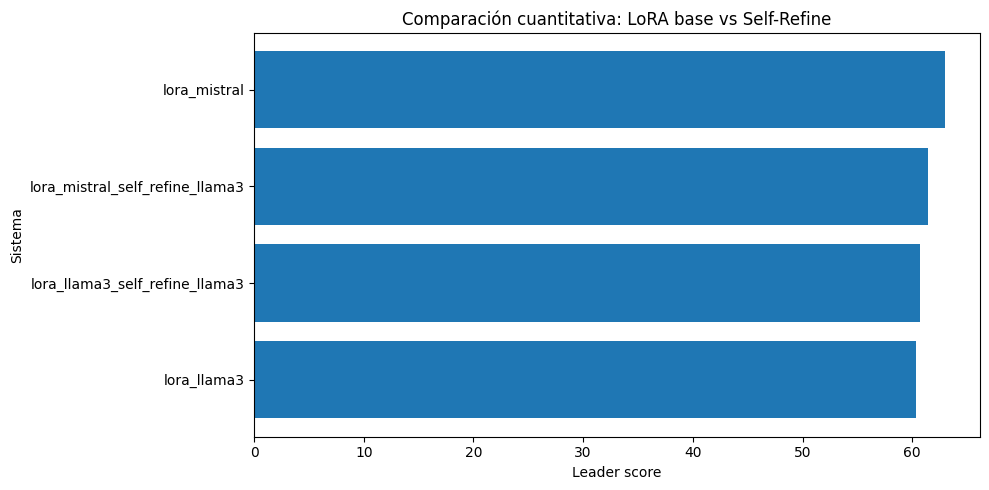

In [25]:
plot_df = ranking_quant.sort_values("leader_score", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["system_name"], plot_df["leader_score"])
plt.xlabel("Leader score")
plt.ylabel("Sistema")
plt.title("Comparación cuantitativa: LoRA base vs Self-Refine")
plt.tight_layout()
plt.show()

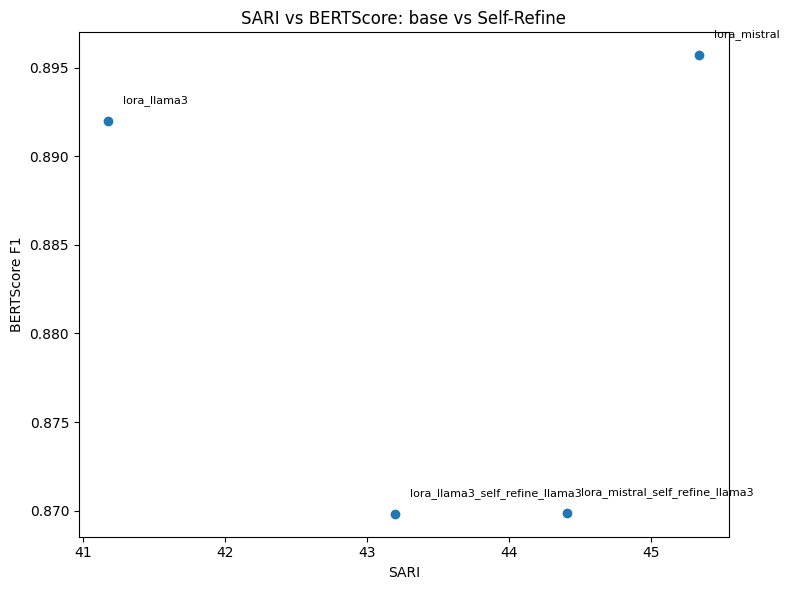

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ranking_quant["sari"],
    ranking_quant["bertscore_f1"],
)

for _, row in ranking_quant.iterrows():
    plt.text(
        row["sari"] + 0.1,
        row["bertscore_f1"] + 0.001,
        row["system_name"],
        fontsize=8,
    )

plt.xlabel("SARI")
plt.ylabel("BERTScore F1")
plt.title("SARI vs BERTScore: base vs Self-Refine")
plt.tight_layout()
plt.show()

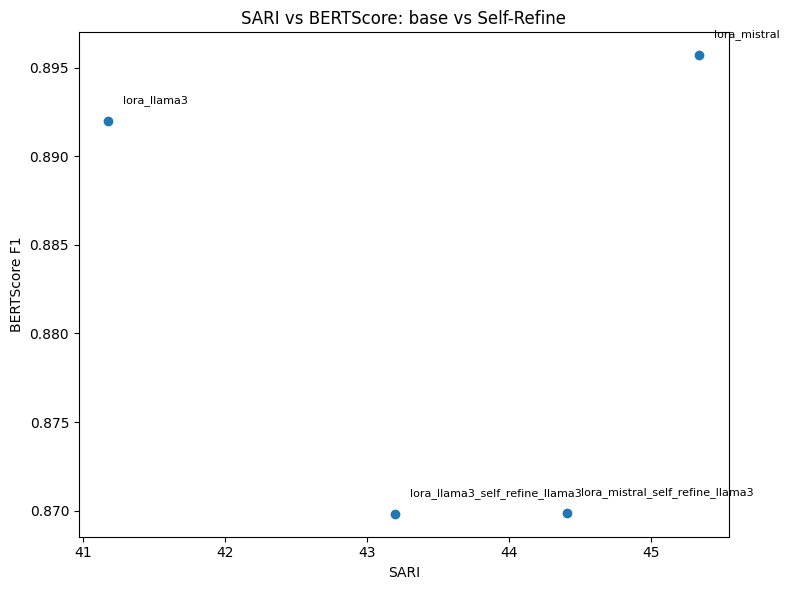

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ranking_quant["sari"],
    ranking_quant["bertscore_f1"],
)

for _, row in ranking_quant.iterrows():
    plt.text(
        row["sari"] + 0.1,
        row["bertscore_f1"] + 0.001,
        row["system_name"],
        fontsize=8,
    )

plt.xlabel("SARI")
plt.ylabel("BERTScore F1")
plt.title("SARI vs BERTScore: base vs Self-Refine")
plt.tight_layout()
plt.show()

In [28]:
ALL_EVAL_PATH = OUT_DIR / "03_base_vs_self_refine_metrics_all.csv"
SUMMARY_PATH = OUT_DIR / "05_resumen_base_vs_self_refine.csv"
COMPARISON_PATH = OUT_DIR / "06_comparacion_deltas_base_vs_self_refine.csv"
SIDE_BY_SIDE_PATH = OUT_DIR / "07_ejemplos_base_vs_self_refine.csv"
EXCEL_PATH = OUT_DIR / "self_refine_top2_lora_resultados.xlsx"

df_all_eval.to_csv(ALL_EVAL_PATH, index=False, encoding="utf-8-sig")
summary_all.to_csv(SUMMARY_PATH, index=False, encoding="utf-8-sig")
comparison_summary.to_csv(COMPARISON_PATH, index=False, encoding="utf-8-sig")
side_by_side.to_csv(SIDE_BY_SIDE_PATH, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl") as writer:
    summary_all.to_excel(writer, sheet_name="Resumen cuantitativo", index=False)
    comparison_summary.to_excel(writer, sheet_name="Deltas base vs refine", index=False)
    ranking_quant.to_excel(writer, sheet_name="Ranking cuantitativo", index=False)
    side_by_side.to_excel(writer, sheet_name="Ejemplos lado a lado", index=False)
    df_all_eval.to_excel(writer, sheet_name="Detalle metricas", index=False)
    self_refine_clean.to_excel(writer, sheet_name="Raw self refine", index=False)

print("Archivos guardados:")
print("-", SELF_REFINE_RAW_PATH)
print("-", REFINED_METRICS_PATH)
print("-", ALL_EVAL_PATH)
print("-", SUMMARY_PATH)
print("-", COMPARISON_PATH)
print("-", SIDE_BY_SIDE_PATH)
print("-", RUBRIC_SELF_REFINE_PATH)
print("-", EXCEL_PATH)

Archivos guardados:
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/01_self_refine_top2_lora_raw.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/02_self_refine_top2_lora_metrics.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/03_base_vs_self_refine_metrics_all.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/05_resumen_base_vs_self_refine.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/06_comparacion_deltas_base_vs_self_refine.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/07_ejemplos_base_vs_self_refine.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/04_para_rubrica_self_refine_top2_lora.xlsx
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/self_refine_top2_lora_resultados.xlsx
